In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import os
import sys
sys.path.append(os.path.abspath("../src/"))

import pickle
import utils as utils
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm
from sklearn.datasets import load_wine
from sklearn import preprocessing
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.cluster import normalized_mutual_info_score

import torch.nn.functional as F
from collections import OrderedDict

np.random.seed(1)

In [2]:
def load_and_plot_graph(file_path, plot=False):
    # Load the graph
    with open(file_path, 'rb') as f:
        G = pickle.load(f)
    
    # Ensure the loaded object is a NetworkX graph
    if not isinstance(G, nx.Graph):
        raise TypeError("The loaded object is not a NetworkX graph.")
    
    if plot:
        # Plot the graph using a spring layout
        plt.figure(figsize=(5, 3))
        pos = nx.spring_layout(G)
        nx.draw(G, pos, with_labels=True, node_color='lightblue', font_weight='bold', node_size=700, font_size=12)
        plt.title('Graph')
        plt.show()
    return G

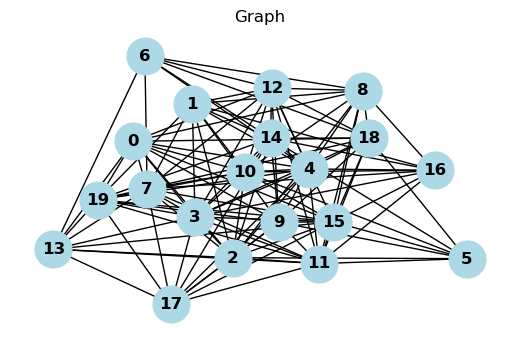

In [3]:
model  = 'erdos_renyi'
number_of_nodes = 20
prob = 0.7
simulation_number = 0
DATA_PATH = '../src/data'
file_extension = 'pkl'

graph_file_path = f'{DATA_PATH}/inputs/{model}/graph_info_{number_of_nodes}_{prob}_sim_{simulation_number}.{file_extension}'
G = load_and_plot_graph(graph_file_path, plot=True)


In [4]:
# Assuming the SAE class is already defined as provided earlier
def graph_to_adjacency_matrix(G):
    """Convert a NetworkX graph to an adjacency matrix (PyTorch tensor)."""
    A = nx.adjacency_matrix(G)
    return torch.tensor(A.toarray(), dtype=torch.float32)

def graph_to_similarity_matrix(G):
    """ Convert a NetworkX graph to a similarity matrix (numpy array). """
    return nx.to_numpy_array(G)

def calculate_degree_matrix(S):
    """ Calculate the degree matrix for the similarity matrix. """
    degrees = np.sum(S, axis=1)
    D = np.diag(degrees)
    return D

def preprocess_graph(G):
    """ Preprocess the graph and return D^-1 * S """
    S = graph_to_similarity_matrix(G)
    D = calculate_degree_matrix(S)
    D_inv = np.linalg.inv(D)
    return torch.tensor(np.dot(D_inv, S), dtype=torch.float32)

# Example with SAE embeddings

In [5]:
adjacency_matrix = nx.adjacency_matrix(G)
adjacency_matrix = np.array(adjacency_matrix.todense())

In [6]:
degree_dict = dict(G.degree())
n = len(degree_dict)
degree_matrix = np.zeros((n, n), dtype=int)
np.fill_diagonal(degree_matrix, list(degree_dict.values()))

In [7]:
degree_matrix_inv = np.linalg.inv(degree_matrix + np.eye(degree_matrix.shape[0])) - np.eye(degree_matrix.shape[0])
embedding_input = np.matmul(degree_matrix_inv, adjacency_matrix)
print('visualize embedding input')
print(embedding_input.shape)

visualize embedding input
(20, 20)


In [8]:
from models.SAE import SAE

In [9]:
device = 'cpu'
device = torch.device('cuda' if device == 'gpu' else 'cpu')

###########################
epoch = 100
lr=  0.01
rho = 0.5 # prior rho
layers = [32, 16, 32]
beta = 0.01 # Sparsity penalty parameter

G = nx.erdos_renyi_graph(n=100, p=0.5)
X_train = preprocess_graph(G)
X_train = X_train.float().to(device)
###########################

layers = [len(X_train)] + layers + [len(X_train)] # lin 1 + lin 2 + lin 3 + lin4

model = SAE(layers).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

with tqdm(total=epoch) as tq:
    for epoch in range(1, epoch + 1):
        optimizer.zero_grad()
        X_hat = model(X_train)
        loss = model.loss(X_hat, X_train, beta, rho)

        loss.backward()
        optimizer.step()

        #tq.set_postfix(loss='{:.3f}'.format(loss), nmi='{:.3f}'.format(nmi))

        tq.update()

    emb = model.get_embedding('lin2')

100%|██████████| 100/100 [00:00<00:00, 218.51it/s]


In [10]:
model

SAE(
  (layers): Sequential(
    (lin1): Linear(in_features=100, out_features=32, bias=True)
    (sig1): Sigmoid()
    (lin2): Linear(in_features=32, out_features=16, bias=True)
    (sig2): Sigmoid()
    (lin3): Linear(in_features=16, out_features=32, bias=True)
    (sig3): Sigmoid()
    (lin4): Linear(in_features=32, out_features=100, bias=True)
    (sig4): Sigmoid()
  )
)

In [11]:
print(X_train.shape)
print(emb.shape)

torch.Size([100, 100])
(100, 16)


## Testing for multiple graphs

In [40]:
import glob
model  = 'erdos_renyi'
number_of_nodes = 20
DATA_PATH = '../src/data'
file_extension = 'pkl'

G_with_prob5 = []
G_with_prob7 = []

########
prob = 0.5
graph_file_pattern = f'{DATA_PATH}/inputs/{model}/graph_info_{number_of_nodes}_{prob}_sim_*.{file_extension}'
graph_file_paths = glob.glob(graph_file_pattern) # Use glob to get a list of all matching file paths
for graph_file_path in graph_file_paths:
    print(graph_file_path)
    G = load_and_plot_graph(graph_file_path, plot=False)
    G_with_prob5.append(G)
print()
########
prob = 0.7
graph_file_pattern = f'{DATA_PATH}/inputs/{model}/graph_info_{number_of_nodes}_{prob}_sim_*.{file_extension}'
graph_file_paths = glob.glob(graph_file_pattern) # Use glob to get a list of all matching file paths
for graph_file_path in graph_file_paths:
    print(graph_file_path)
    G = load_and_plot_graph(graph_file_path, plot=False)
    G_with_prob7.append(G)


../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_8.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_9.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_18.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_19.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_1.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_14.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_15.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_0.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_2.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_17.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_16.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_3.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_7.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_12.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_13.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_6.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5

# Spearman correlation of eigenvalues example usage

In [4]:
import glob
model  = 'erdos_renyi'
number_of_nodes = 20
DATA_PATH = '../src/data'
file_extension = 'pkl'

G_with_prob5 = []
G_with_prob7 = []

########
prob = 0.5
graph_file_pattern = f'{DATA_PATH}/inputs/{model}/graph_info_{number_of_nodes}_{prob}_sim_*.{file_extension}'
graph_file_paths = glob.glob(graph_file_pattern) # Use glob to get a list of all matching file paths
for graph_file_path in graph_file_paths:
    print(graph_file_path)
    G = load_and_plot_graph(graph_file_path, plot=False)
    G_with_prob5.append(G)
print()
########
prob = 0.7
graph_file_pattern = f'{DATA_PATH}/inputs/{model}/graph_info_{number_of_nodes}_{prob}_sim_*.{file_extension}'
graph_file_paths = glob.glob(graph_file_pattern) # Use glob to get a list of all matching file paths
for graph_file_path in graph_file_paths:
    print(graph_file_path)
    G = load_and_plot_graph(graph_file_path, plot=False)
    G_with_prob7.append(G)


../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_8.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_9.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_18.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_19.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_1.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_14.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_15.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_0.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_2.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_17.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_16.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_3.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_7.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_12.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_13.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5_sim_6.pkl
../src/data/inputs/erdos_renyi/graph_info_20_0.5

In [6]:
from models.Spectrum import Spectrum
analysis = Spectrum()

# Get the adjacency matrix of the graphs
G_with_prob5_adj = [ nx.adjacency_matrix(graph).toarray() for graph in G_with_prob5 ]
G_with_prob7_adj = [ nx.adjacency_matrix(graph).toarray() for graph in G_with_prob7 ]

#analysis.compute_largest_eigenvalues(G_with_prob5_adj)

analysis.calculate_spearman_correlation(G_with_prob5_adj, G_with_prob7_adj)

-0.3203007518796992